In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Visualizing Contributor Co-occurrence in the ProvedIt Dataset

This notebook explores the contributor structure of the ProvedIt dataset. The goal is to analyze how contributors co-occur within files and visualize their relationships using an arc diagram.

In [2]:
from itertools import combinations
from collections import Counter
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer, categorize_files
from DNAnet.data.parsing.file_parsing import find_files_by_suffix

import matplotlib.pyplot as plt
import numpy as np
import re

# Load Dataset Files

- Specify the path to the dataset and load all files with the `.hid` suffix. These files are used to extract contributor information.
- Categorize the loaded files using the custom file categorizer and extract the subset of files labeled as 'sample', which represent mixture samples.
- Display the number of mixture samples identified in the dataset.

In [3]:
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
hid_files = find_files_by_suffix(hid_files_path, ".hid")

categorized_files = categorize_files(hid_files, ProvedItFileCategorizer())
mixture_samples = categorized_files["sample"]

len(mixture_samples)

675

## Extract and Count Contributor Pairs

Extract all contributor pairs from the files and count the frequency of each pair's co-occurrence.

In [4]:
def extract_all_pairs(files):
    pairs = []
    for f in files:
        ids = ProvedItFileCategorizer.extract_contributor_ids(f.name)
        # Only consider files with at least 2 contributors
        if len(ids) >= 2:
            # Get all unique pairs (order doesn't matter)
            pairs.extend(combinations(sorted(ids), 2))
    return pairs

In [5]:
pairs = extract_all_pairs(mixture_samples)
pairs_count = Counter(pairs)
pairs_count.most_common(10)

[((33, 34), 122),
 ((36, 37), 107),
 ((29, 50), 100),
 ((44, 45), 99),
 ((31, 32), 98),
 ((37, 38), 97),
 ((29, 49), 84),
 ((49, 50), 84),
 ((30, 31), 83),
 ((46, 47), 83)]

## Visualize Contributor Co-occurrence

Define a function to visualize contributor co-occurrence as an arc diagram. Each contributor is represented along a line, and arcs connect contributors who appear together in the same file.

In [6]:
def plot_arc_diagram(pairs, num_ids=50):
    plt.figure(figsize=(16, 4))
    y = np.zeros(num_ids)
    x = np.arange(1, num_ids + 1)
    plt.scatter(x, y, s=50, color='black')

    for a, b in pairs:
        # Draw an arc between a and b
        mid = (a + b) / 2
        radius = abs(b - a) / 2
        theta = np.linspace(0, np.pi, 100)
        arc_x = mid + radius * np.cos(theta)
        arc_y = radius * np.sin(theta)
        plt.plot(arc_x, arc_y, color='blue', alpha=0.3)

    plt.yticks([])
    plt.xlabel("Contributor ID")
    plt.title("Contributor Co-occurrence Arc Diagram")
    plt.show()

## Plot the Arc Diagram

Generate and display the arc diagram to visualize the relationships between contributors based on their co-occurrence in files.

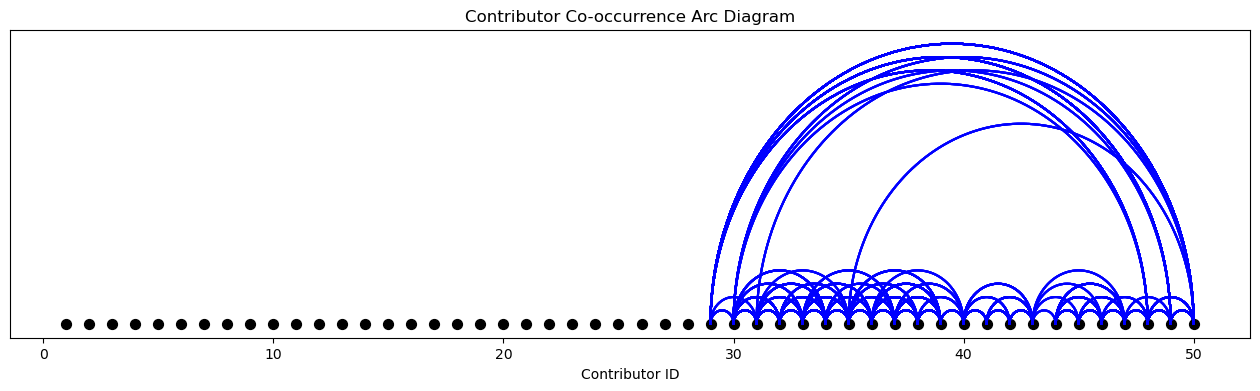

In [7]:
plot_arc_diagram(pairs)

# Constructing Graphs of Contributor Interconnectivity

We will construct two types of graphs:
1. A weighted undirected graph where nodes are contributors and edges represent co-occurrence in files, weighted by the number of co-occurrences.
2. A bipartite graph with files on one side and contributors on the other, with edges indicating which contributors are present in which files.

## Weighted Graph

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import nxmetis
from sklearn.cluster import SpectralClustering

In [9]:
# 1. Weighted undirected graph of contributor co-occurrence
G_contrib = nx.Graph()
for (a, b), weight in pairs_count.items():
    G_contrib.add_edge(a, b, weight=weight)

print(f"Contributor graph: {G_contrib.number_of_nodes()} nodes, {G_contrib.number_of_edges()} edges")


Contributor graph: 22 nodes, 64 edges


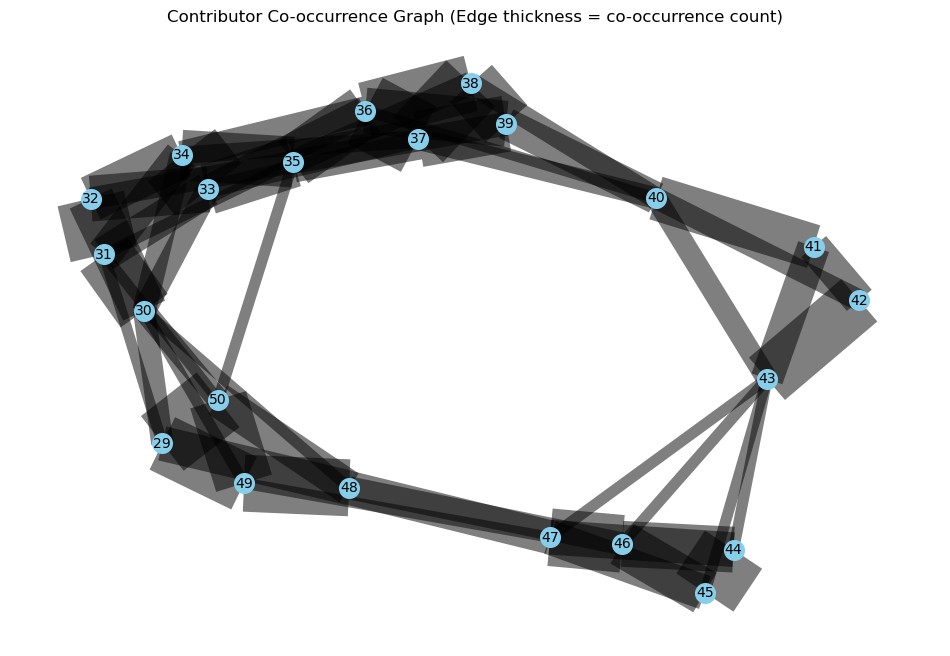

In [10]:
# 1. Visualize the weighted contributor co-occurrence graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_contrib, seed=42, k=0.5)
edges = G_contrib.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]
nx.draw_networkx_nodes(G_contrib, pos, node_size=200, node_color='skyblue')
nx.draw_networkx_edges(G_contrib, pos, width=[w/2 for w in weights], alpha=0.5) # type: ignore
nx.draw_networkx_labels(G_contrib, pos, font_size=10)
plt.title("Contributor Co-occurrence Graph (Edge thickness = co-occurrence count)")
plt.axis('off')
plt.show()

## Splitting the Graph into Communities (using spectral clustering)

In [11]:
# # Option A: Use Stoer-Wagner for 2 sets
# cut_value, partition = nx.stoer_wagner(G_contrib)
# partitions = [set(partition[0]), set(partition[1])]


# # Option B: Use METIS for partitioning
# # Make a fresh graph for METIS compatibility
# G_metis = nx.Graph()

# # Add nodes (METIS doesn't need attributes for nodes)
# G_metis.add_nodes_from(G_contrib.nodes())

# # Add edges with METIS-compatible weight attribute
# for u, v, data in G_contrib.edges(data=True):
#     weight = data.get('weight', 1)
#     G_metis.add_edge(u, v, weight=weight)

# # Now partition
# edgecuts, partitions = nxmetis.partition(G_metis, 2)

# print("Edge cuts:", edgecuts)
# print("Partition 1:", partitions[0])
# print("Partition 2:", partitions[1])

# # Check if partitions meet your minimum size constraint
# if len(partitions[0]) >= 3 and len(partitions[1]) >= 3:
#     print("Valid partition found!")
# else:
#     print("One partition is too small. Try another seed or fallback.")

# Option C: Use scikit's spectral clustering

# Build adjacency matrix
nodes = list(G_contrib.nodes())
node_idx = {node: i for i, node in enumerate(nodes)}
A = np.zeros((len(nodes), len(nodes)))

for u, v, data in G_contrib.edges(data=True):
    i, j = node_idx[u], node_idx[v]
    A[i, j] = A[j, i] = data.get("weight", 1)

# Run spectral clustering
clustering = SpectralClustering(n_clusters=2, affinity='precomputed', assign_labels='kmeans')
labels = clustering.fit_predict(A)

# Extract partitions
part0 = [nodes[i] for i in range(len(nodes)) if labels[i] == 0]
part1 = [nodes[i] for i in range(len(nodes)) if labels[i] == 1]

# Option D: Use pymetis

### Visualize weighted graph split

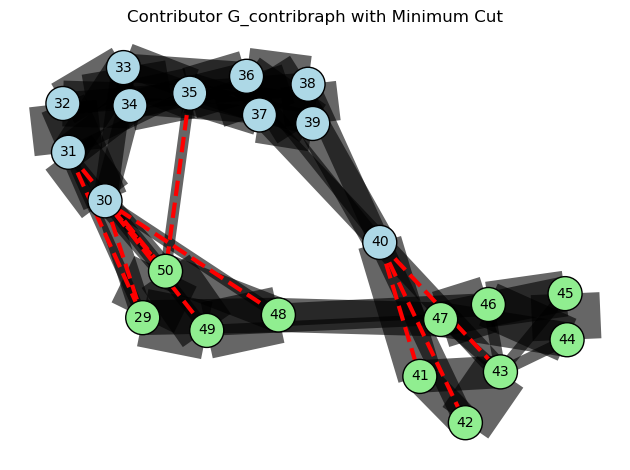

In [12]:
pos = nx.spring_layout(G_contrib, seed=42)  # Layout positions (force-directed)

# part_a = partitions[0]
# part_b = partitions[1]
part_a = set(part0)
part_b = set(part1)

# Color nodes by partition
node_colors = []
for node in G_contrib.nodes():
    if node in part_a:
        node_colors.append("lightblue")
    else:
        node_colors.append("lightgreen")

# Draw edges (thickness proportional to weight)
edge_weights = [G_contrib[u][v]['weight'] for u, v in G_contrib.edges()]
nx.draw_networkx_edges(G_contrib, pos, width=[w * 0.5 for w in edge_weights], alpha=0.6)

# Draw nodes
nx.draw_networkx_nodes(G_contrib, pos, node_color=node_colors, node_size=600, edgecolors='k')
nx.draw_networkx_labels(G_contrib, pos, font_size=10)

# Optional: Highlight cut edges (between partitions)
cut_edges = [(u, v) for u, v in G_contrib.edges() if (u in part_a and v in part_b) or (v in part_a and u in part_b)]
nx.draw_networkx_edges(G_contrib, pos, edgelist=cut_edges, width=3, edge_color="red", style='dashed')

plt.title("Contributor G_contribraph with Minimum Cut")
plt.axis("off")
plt.tight_layout()
plt.show()

## Bipartite Graph

In [13]:
# 2. Bipartite graph: files <-> contributors
B = nx.Graph()
file_nodes = []
contrib_nodes = set()

for f in mixture_samples:
    file_id = f.name  # or use f.path if you want full path
    file_nodes.append(file_id)
    contribs = ProvedItFileCategorizer.extract_contributor_ids(f.name)
    for c in contribs:
        B.add_edge(file_id, c)
        contrib_nodes.add(c)

# Mark node attributes for bipartite sets
for f in file_nodes:
    B.nodes[f]['bipartite'] = 0  # files
for c in contrib_nodes:
    B.nodes[c]['bipartite'] = 1  # contributors

print(f"Bipartite graph: {len(file_nodes)} file nodes, {len(contrib_nodes)} contributor nodes, {B.number_of_edges()} edges")


Bipartite graph: 675 file nodes, 22 contributor nodes, 2341 edges


### Splitting the bipartite graph into communities

In [14]:
# Create a lookup: file -> set of contributors
file_to_contribs = {f: set(B.neighbors(f)) for f in file_nodes}

# Shuffle or sort to influence behavior
sorted_files = sorted(file_nodes, key=lambda f: len(file_to_contribs[f]))

# Partition containers
partitions = {"A": set(), "B": set()}
contributors_in = {"A": set(), "B": set()}
unassigned_files = set(file_nodes)

# Helper: assign file to partition
def assign_file(f, part):
    partitions[part].add(f)
    contributors_in[part].update(file_to_contribs[f])
    unassigned_files.discard(f)

# Step 1: Seed one file per partition (non-overlapping contributors)
assign_file(sorted_files[0], "A")
for f in sorted_files[1:]:
    if file_to_contribs[f].isdisjoint(contributors_in["A"]):
        assign_file(f, "B")
        break

# Step 2: Greedy assignment
for f in sorted_files:
    if f not in unassigned_files:
        continue
    cset = file_to_contribs[f]
    can_A = cset.isdisjoint(contributors_in["A"])
    can_B = cset.isdisjoint(contributors_in["B"])

    if can_A and (len(partitions["A"]) < len(partitions["B"]) or not can_B):
        assign_file(f, "A")
    elif can_B:
        assign_file(f, "B")
    else:
        continue  # can't assign without overlap

# Step 3: Enforce minimum size constraint
if len(partitions["A"]) < 3 or len(partitions["B"]) < 3:
    print("⚠️ No valid split with ≥3 files per side found.")
else:
    print(f"✅ Partition A: {len(partitions['A'])} files, Partition B: {len(partitions['B'])} files")
    print(f"Unassigned: {len(unassigned_files)} files")

# Optional: Inspect contributors per partition
#print("Contributors in A:", contributors_in["A"])
#print("Contributors in B:", contributors_in["B"])


✅ Partition A: 8 files, Partition B: 8 files
Unassigned: 659 files


### Visualize bipartite Graph

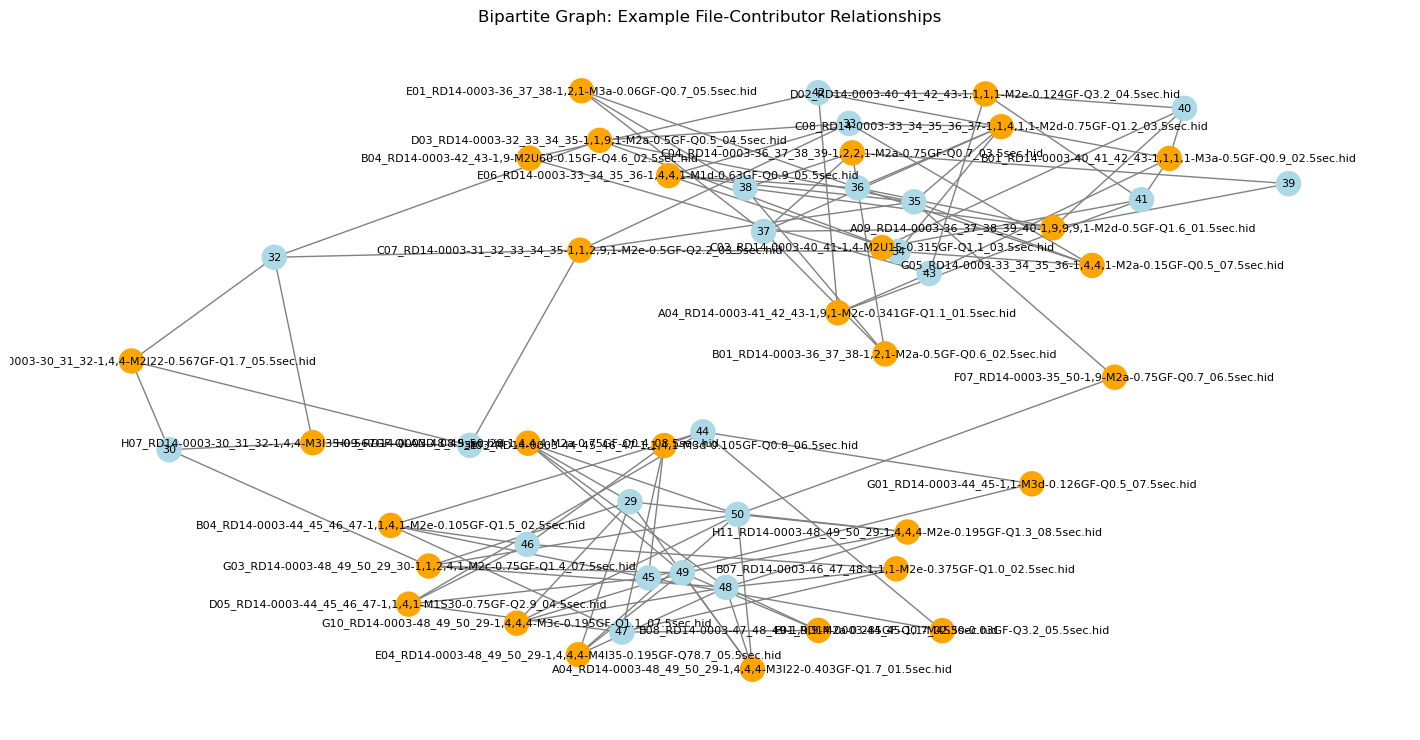

In [15]:
# Optionally, visualize a small subgraph of the bipartite graph (files and contributors)
# Pick a random sample of files and their contributors for visualization
sampled_files = random.sample(list(file_nodes), min(30, len(file_nodes)))
sub_nodes = set(sampled_files)
for f in sampled_files:
    sub_nodes.update(B.neighbors(f))
subgraph = B.subgraph(sub_nodes)

plt.figure(figsize=(14, 7))
pos = nx.spring_layout(subgraph, seed=42, k=0.7)
node_colors = ['orange' if n in sampled_files else 'lightblue' for n in subgraph.nodes()]
nx.draw(subgraph, pos, with_labels=True, node_color=node_colors, node_size=300, font_size=8, edge_color='gray')
plt.title("Bipartite Graph: Example File-Contributor Relationships")
plt.axis('off')
plt.show()

# Ultimate Separation Heuristic

In [42]:
# Step 1: Define contributor set of interest (Community A)
community_A_contributors = {39, 40, 41, 42, 43}  # Keep as strings if IDs are strings

# Step 2: Classify files
community_A_files = []
community_B_files = []
ambiguous_files = []

for f in mixture_samples:
    contribs = set(ProvedItFileCategorizer.extract_contributor_ids(f.name))
    # print(f"File: {f.name}, Contributors: {contribs}")

    if contribs.issubset(community_A_contributors):
        community_A_files.append(f)
    elif contribs.isdisjoint(community_A_contributors):
        community_B_files.append(f)
    else:
        ambiguous_files.append(f)  # contributors from both groups, discard or flag

# Step 3: Reporting
print(f"✅ Community A: {len(community_A_files)} files")
print(f"✅ Community B: {len(community_B_files)} files")
print(f"⚠️ Ambiguous: {len(ambiguous_files)} files discarded due to overlap")

ind = 2
community_A_files[:ind], community_B_files[:ind], ambiguous_files[:ind]

✅ Community A: 128 files
✅ Community B: 450 files
⚠️ Ambiguous: 97 files discarded due to overlap


([PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/B10_RD14-0003-39_40-1,2-M3a-0.045GF-Q0.8_02.5sec.hid'),
  PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/F10_RD14-0003-39_40-1,2-M3c-0.045GF-Q1.0_06.5sec.hid')],
 [PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/F01_RD14-0003-31_32-1,1-M1c-0.25GF-Q3.0_06.5sec.hid'),
  PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/D04_RD14-0003-33_34-1,2-M4d-0.093GF-Q1.3_04.5sec.hid')],
 [PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516

# Extract Mixture Ratios from Filenames

We define a function to extract the mixture ratios from each filename. The mixture ratio is found as a comma-separated list after the contributor IDs. For example, in the filename `A05_RD14-0003-32_33_34_35-1,1,9,1-M2e-0.372GF-Q0.6_01.5sec.hid`, the mixture ratio is `1,1,9,1`.

In [43]:
def extract_mixture_ratios(file_name):
    """
    Extracts the mixture ratios from a ProvedIt filename as a list of integers.
    Returns an empty list if not found.
    """
    # Look for the pattern after the contributor IDs: -1,1,9,1-
    match = re.search(r"RD14-0003-[\d_]+-([\d,]+)-", file_name)
    if match:
        ratio_str = match.group(1)
        return [int(x) for x in ratio_str.split(",") if x.isdigit()]
    return []

## Aggregate Mixture Ratios

We extract the mixture ratios for all files and aggregate them for further analysis and visualization.

In [44]:
all_mixture_ratios = [extract_mixture_ratios(f.name) for f in mixture_samples]
all_mixture_ratios[:5]  # Show a sample

comm_a_mixture_ratios = [extract_mixture_ratios(f.name) for f in community_A_files]

## Visualize Contributor Mixes as Sets of (Ratio, Count) Tuples

We represent each mixture as a set of (ratio, count) tuples, where each tuple indicates a unique ratio and how many contributors have that ratio. The order of tuples does not matter. We then group and count all unique sets and visualize their frequencies as a bar chart.

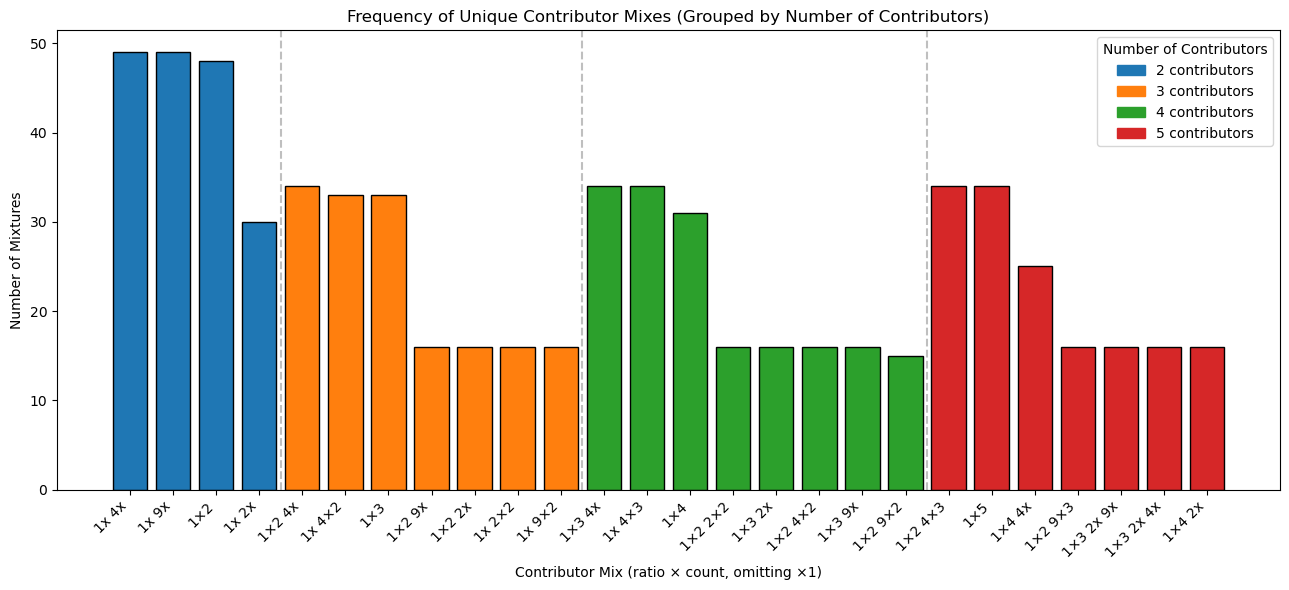

In [38]:
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

def mixture_to_tuple_set(mixture):
    c = Counter(mixture)
    return frozenset((ratio, count) for ratio, count in sorted(c.items()))

# Aggregate all unique sets and group by number of contributors
mixture_sets = [mixture_to_tuple_set(r) for r in all_mixture_ratios if r]
set_counts = Counter(mixture_sets)

# Group by number of contributors
grouped = defaultdict(list)
for s, count in set_counts.items():
    n_contrib = sum(cnt for _, cnt in s)
    grouped[n_contrib].append((s, count))

# Prepare for plotting
colors = plt.cm.tab10.colors  # Up to 10 groups, can expand if needed
all_labels = []
all_counts = []
all_colors = []
group_positions = []
current_pos = 0

for idx, n_contrib in enumerate(sorted(grouped.keys())):
    group = grouped[n_contrib]
    # Sort by count descending
    group_sorted = sorted(group, key=lambda x: -x[1])
    for s, count in group_sorted:
        label = " ".join(
            f"{ratio}x" if cnt == 1 else f"{ratio}×{cnt}"
            for ratio, cnt in sorted(s)
        )
        all_labels.append(label)
        all_counts.append(count)
        all_colors.append(colors[idx % len(colors)])
    group_positions.append(current_pos)
    current_pos += len(group_sorted)

plt.figure(figsize=(max(12, len(all_labels) * 0.5), 6))
bars = plt.bar(range(len(all_counts)), all_counts, color=all_colors, edgecolor='black')
plt.xticks(range(len(all_labels)), all_labels, rotation=45, ha='right')
plt.xlabel('Contributor Mix (ratio × count, omitting ×1)')
plt.ylabel('Number of Mixtures')
plt.title('Frequency of Unique Contributor Mixes (Grouped by Number of Contributors)')

# Add legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=colors[idx % len(colors)], label=f'{n_contrib} contributors')
    for idx, n_contrib in enumerate(sorted(grouped.keys()))
]
plt.legend(handles=legend_handles, title='Number of Contributors')

# Optionally, add vertical lines to separate groups
for pos in group_positions[1:]:
    plt.axvline(pos - 0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [39]:
import numpy as np

def gini_coefficient(x):
    """Compute the Gini coefficient of a list of numbers."""
    x = np.array(x)
    if np.amin(x) < 0:
        raise ValueError("Values cannot be negative")
    if np.amin(x) == 0 and np.amax(x) == 0:
        return 0.0
    x_sorted = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x_sorted)
    gini = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
    return gini

# Compute Gini for each mixture
gini_per_mixture = [gini_coefficient(r) for r in all_mixture_ratios if r]
# compute Gini for community A mixtures
gini_comm_a = [gini_coefficient(r) for r in comm_a_mixture_ratios if r]

# Group by number of contributors
gini_by_group = defaultdict(list)
for r, g in zip(all_mixture_ratios, gini_per_mixture):
    n = len(r)
    gini_by_group[n].append(g)

# Calculate average Gini per group
avg_gini_by_group = {n: np.mean(ginis) for n, ginis in gini_by_group.items()}

# Calculate average Gini over the whole dataset
avg_gini_overall = np.mean(gini_per_mixture)

print("Average Gini coefficient by number of contributors:")
for n in sorted(avg_gini_by_group):
    print(f"{n} contributors: {avg_gini_by_group[n]:.3f}")

print(f"\nAverage Gini coefficient over all mixtures: {avg_gini_overall:.3f}")

# Calculate average Gini over community A
avg_gini_comm_a = np.mean(gini_comm_a)
print(f"\nAverage Gini coefficient for Community A mixtures: {avg_gini_comm_a:.3f}")

Average Gini coefficient by number of contributors:
2 contributors: 0.223
3 contributors: 0.218
4 contributors: 0.229
5 contributors: 0.232

Average Gini coefficient over all mixtures: 0.225

Average Gini coefficient for Community A mixtures: 0.207


In [40]:
np.mean([gini_coefficient([1,1,4]), gini_coefficient([1,4,4]), gini_coefficient([1,1,1]), gini_coefficient([1,1,9]), gini_coefficient([1,1,2]), gini_coefficient([1,2,2]), gini_coefficient([1,9,9])])

0.23158654211285787

# Distribution of number of contributors per mixture

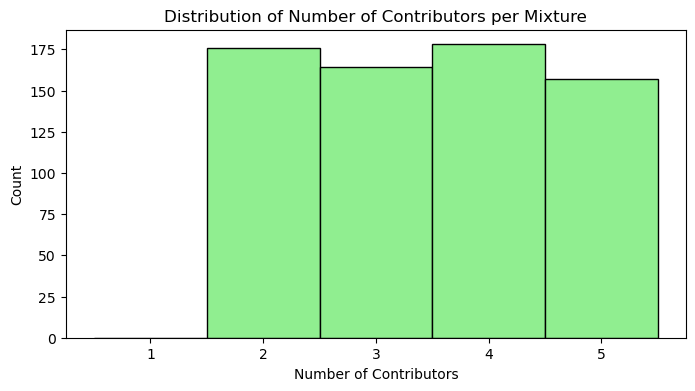

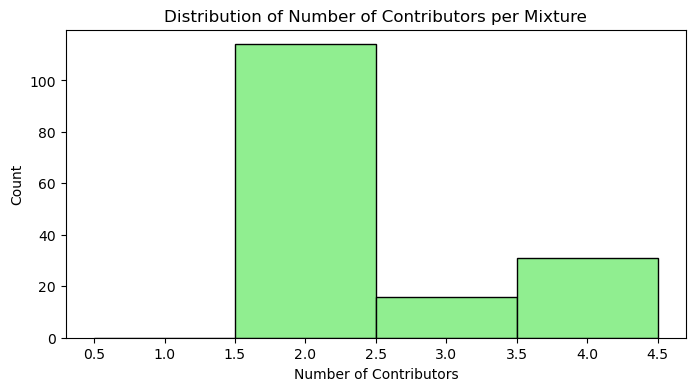

Counter({4: 178, 2: 176, 3: 164, 5: 157})

In [41]:
num_contributors = [len(r) for r in all_mixture_ratios]
comm_a_num_contributors = [len(r) for r in comm_a_mixture_ratios]

for contributor_counts in [num_contributors, comm_a_num_contributors]:
    # Plot histogram of number of contributors
    plt.figure(figsize=(8,4))
    plt.hist(contributor_counts, bins=range(1, max(contributor_counts)+2), align='left', color='lightgreen', edgecolor='black')
    plt.xlabel('Number of Contributors')
    plt.ylabel('Count')
    plt.title('Distribution of Number of Contributors per Mixture')
    plt.show()

# Distribution of number of contributors per mixture
num_contributors_count = Counter(num_contributors)
num_contributors_count